In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Set maximum column width to prevent wrapping
pd.set_option('display.max_colwidth', None)  # Set to None to allow full width
pd.set_option('display.width', 1000)  # Adjust the total width of the display

In [ ]:
# Load the reference and testing data from CSV files
reference_data = pd.read_csv('/content/drive/MyDrive/thesis_dataset/203_all_ref_modified.csv', header=None) # 203 / 204
testing_data = pd.read_csv('/content/drive/MyDrive/thesis_dataset/203_all_test_modified.csv', header=None) # 203 / 204

# Extract names, features, and labels from the reference data
reference_names = reference_data.iloc[1:, 0].values
X_train = reference_data.iloc[1:, 1:-1].values
y_train = reference_data.iloc[1:, -1].values

# Extract names, features, and labels from the testing data
testing_names = testing_data.iloc[1:, 0].values
X_test = testing_data.iloc[1:, 1:-1].values
y_test = testing_data.iloc[1:, -1].values

In [ ]:
k = 5
distance_metric = 'manhattan'  # Choose from 'euclidean', 'manhattan', 'cosine', 'hamming'

knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metric)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(f"Accuracy on test set (k={k}, metric='{distance_metric}'): {accuracy_score(y_test, y_pred)}")
print("Classification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
labels = ['Inside', 'Outside']
cm_df = pd.DataFrame(cm, index=[f'Actual {label}' for label in labels],
                        columns=[f'Predicted {label}' for label in labels])
print("Confusion Matrix (Actual vs. Predicted):\n", cm_df)


# Create DataFrame for evaluation
results_df_knn = pd.DataFrame({
    'Testing Point': testing_names,
    'Actual': y_test,
    'Predicted': y_pred
})

# Define a function to apply both background and font color for mismatches
def highlight_mismatch(row):
    if row['Actual'] != row['Predicted']:
        return ['background-color: yellow; color: red'] * len(row)
    else:
        return [''] * len(row)

# Apply the highlighting function with font color change
styled_results_df = results_df_knn.style.apply(highlight_mismatch, axis=1)

# Display the styled DataFrame with mismatches highlighted
styled_results_df

Accuracy on test set (k=5, metric='manhattan'): 0.9230769230769231
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.82      0.90        17
         1.0       0.88      1.00      0.94        22

    accuracy                           0.92        39
   macro avg       0.94      0.91      0.92        39
weighted avg       0.93      0.92      0.92        39

Confusion Matrix (Actual vs. Predicted):
                 Predicted Inside  Predicted Outside
Actual Inside                 14                  3
Actual Outside                 0                 22


,Testing Point,Actual,Predicted
0,CSE_203_testing_09_o,0.000000,0.000000
1,CSE_203_testing_05_i,1.000000,1.000000
2,CSE_203_testing_22_o,0.000000,0.000000
3,CSE_203_testing_03_i,1.000000,1.000000
4,CSE_203_testing_07_i,1.000000,1.000000
5,CSE_203_testing_20_i,1.000000,1.000000
6,CSE203_Day1_testing_05_i,1.000000,1.000000
7,CSE203_Day1_testing_07_i,1.000000,1.000000
8,CSE_203_testing_01_i,1.000000,1.000000
9,CSE203_Day1_testing_09_i,1.000000,1.000000


In [ ]:
# Get the k-nearest neighbors (indices) for each test point
_, indices = knn.kneighbors(X_test)

# Create a DataFrame to store the neighbors for each testing point
neighbor_columns = [f'Neighbor {i + 1}' for i in range(5)]  # Create column names for 5 neighbors
testing_neighbors = []

for i, test_point in enumerate(X_test):
    # Get the neighbor names from the reference names using the indices
    neighbor_names = [reference_names[idx] for idx in indices[i]]

    # Add the testing point info along with its 5 neighbors
    row_data = {
        'Testing Point': testing_names[i],
        'Predicted': y_pred[i],
        **{neighbor_columns[j]: neighbor_names[j] for j in range(5)}  # Assign neighbor names to columns
    }

    testing_neighbors.append(row_data)

neighbors_df = pd.DataFrame(testing_neighbors)

print("\nNeighbors Information for Testing Points:\n", neighbors_df)


Neighbors Information for Testing Points:
                Testing Point  Predicted          Neighbor 1          Neighbor 2          Neighbor 3          Neighbor 4          Neighbor 5
0       CSE_203_testing_09_o        0.0      CSE_203_r0c1_o      CSE_203_r0c2_o      CSE_203_r0c0_o      CSE_203_r1c3_i      CSE_203_r1c1_i
1       CSE_203_testing_05_i        1.0  CSE203_r3c5_demo_o      CSE_203_r2c3_i  CSE203_r3c4_demo_i  CSE203_r4c4_demo_i  CSE203_r2c5_demo_o
2       CSE_203_testing_22_o        0.0      CSE_203_r0c0_o      CSE_203_r0c1_o      CSE_203_r0c2_o      CSE_203_r1c3_i      CSE_203_r1c1_i
3       CSE_203_testing_03_i        1.0  CSE203_r3c5_demo_o      CSE_203_r3c2_i      CSE_203_r4c2_i      CSE_203_r1c3_i      CSE_203_r0c5_o
4       CSE_203_testing_07_i        1.0      CSE_203_r2c3_i  CSE203_r3c5_demo_o      CSE_203_r4c3_i  CSE203_r3c4_demo_i  CSE203_r4c4_demo_i
5       CSE_203_testing_20_i        1.0      CSE_203_r4c3_i  CSE203_r4c4_demo_i  CSE203_r3c4_demo_i  CSE203_r2c4_dem

In [ ]:
k_values = [3, 5, 7]
distance_metrics = ['euclidean', 'manhattan', 'cosine', 'hamming']

results = []

for k in k_values:
    for metric in distance_metrics:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)

        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        results.append({'k': k, 'Metric': metric, 'Accuracy': accuracy})

        print(f"\nClassification Report (k={k}, metric='{metric}'):\n", classification_report(y_test, y_pred))

# Convert results into a DataFrame for easier analysis
results_df = pd.DataFrame(results)

print("\nDetailed Accuracy Results for each k and Metric:\n", results_df)

# combination with the highest accuracy:
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Result: k={best_result['k']}, Metric={best_result['Metric']}, Accuracy={best_result['Accuracy']}")


Classification Report (k=3, metric='euclidean'):
               precision    recall  f1-score   support

         0.0       1.00      0.95      0.97        19
         1.0       0.95      1.00      0.97        18

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.97      0.97      0.97        37


Classification Report (k=3, metric='manhattan'):
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        19
         1.0       1.00      1.00      1.00        18

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37


Classification Report (k=3, metric='cosine'):
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        19
         1.0       1.00      1.00      1.00        18

    accuracy                    

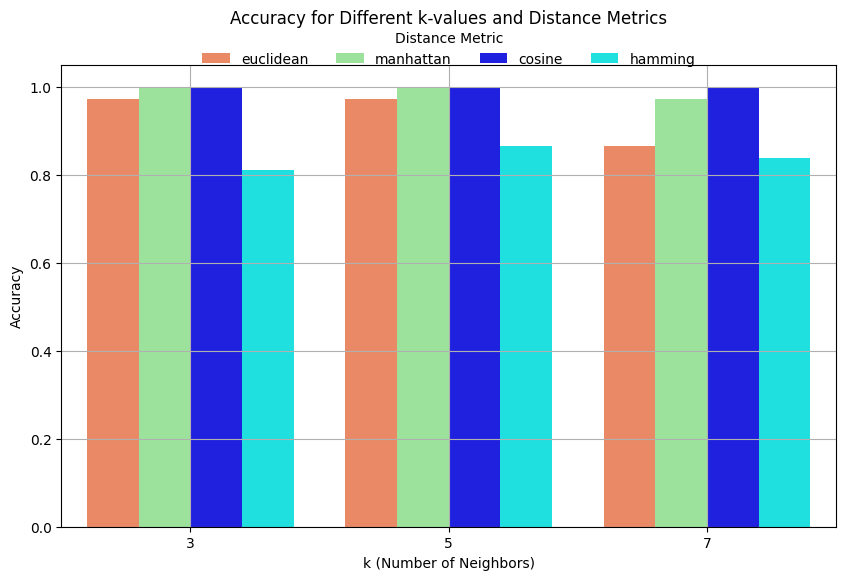

In [ ]:
plt.figure(figsize=(10, 6))

custom_palette = [ 'coral', 'lightgreen', 'blue', 'cyan']

sns.barplot(x='k', y='Accuracy', hue='Metric', data=results_df, palette=custom_palette)

plt.title('Accuracy for Different k-values and Distance Metrics', pad=30)  # Adds extra space between title and plot
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')

# Adjust the legend position so it doesn't collide with the title
plt.legend(title='Distance Metric', loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4, frameon=False)

plt.grid(True)

plt.show()


In [ ]:
ap_names = reference_data.iloc[0, 1:-1].values
ap_names

array(['Galaxy M124213', 'CSE-204', 'CSE-303', 'CSE-304', 'Hall of Fame',
       'DataLab@BUET', 'CSE-206', 'CSE-G04', 'CSE-G07', 'CSE-306',
       'dlink', 'CSE-401'], dtype=object)

Accuracy when AP Galaxy M124213 is absent: 0.8974
Accuracy when AP CSE-204 is absent: 0.9231
Accuracy when AP CSE-303 is absent: 0.8718
Accuracy when AP CSE-304 is absent: 0.9231
Accuracy when AP Hall of Fame is absent: 0.8718
Accuracy when AP DataLab@BUET is absent: 0.8974
Accuracy when AP CSE-206 is absent: 0.8974
Accuracy when AP CSE-G04 is absent: 0.9487
Accuracy when AP CSE-G07 is absent: 0.9231
Accuracy when AP CSE-306 is absent: 0.8974
Accuracy when AP dlink is absent: 0.8718
Accuracy when AP CSE-401 is absent: 0.9231


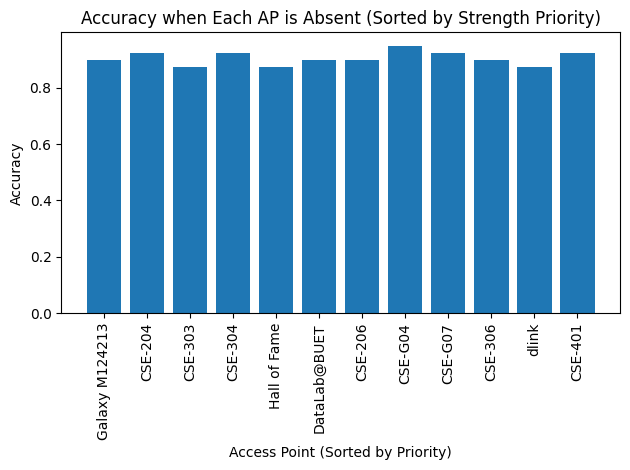

In [ ]:
k = 5
distance_metric = 'manhattan'  # Choose from 'euclidean', 'manhattan', 'cosine', 'hamming'

# Initialize a list to store accuracies when each AP is absent
accuracies = []

# Iterate over each AP (sorted columns) and leave one out at a time
for i in range(X_train.shape[1]):
    # Remove the ith column (AP) from both the training and testing sets
    X_train_reduced = np.delete(X_train, i, axis=1)
    X_test_reduced = np.delete(X_test, i, axis=1)

    knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metric)
    knn.fit(X_train_reduced, y_train)

    y_pred = knn.predict(X_test_reduced)
    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    # Print accuracy for each AP
    print(f"Accuracy when AP {ap_names[i]} is absent: {accuracy:.4f}")

# Plot the accuracies as a bar graph
plt.bar(range(len(accuracies)), accuracies, tick_label=ap_names)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Access Point (Sorted by Priority)')
plt.ylabel('Accuracy')
plt.title('Accuracy when Each AP is Absent (Sorted by Strength Priority)')
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()